# Vol-Risk-Premium -- a quantitative teardown
### 33 years of VIX vs SPY realised vol · HAC inference · quintile sorts · timing overlay · short-vol distribution

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![VRP_premium%3F: Real](https://img.shields.io/badge/VRP_premium%3F-Real-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test the variance risk premium (VRP = VIX - trailing-21d-RV) across three claims: (1) the premium exists (IV > RV), (2) a high VRP predicts forward SPY returns, and (3) a timing rule exploiting (2) beats buy-and-hold.

> **Not investment advice.** Real data: Yahoo Finance `^VIX` + `SPY` daily, as-of 2026-06-12; offline core runs on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **`In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vol_risk_premium import data, strategy as st

_CACHE = os.path.join(os.path.dirname(os.path.abspath(".")), "_cache")

def _have_cache():
    return os.path.exists(data._cache_path(_CACHE))

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)
if HAVE_REAL:
    df = data.fetch_daily(fetch=False, cache_dir=_CACHE)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | VRP premium t = **22.9** (REAL); Q5 forward return t = **2.94** (REAL); Q5-Q1 spread t = **1.67** (below bar); timing spread t = **-1.69** (below bar). |
| **Tradability** | `FRAGILE` | Timer Sharpe 0.50 vs B&H Sharpe 0.55; short-vol skew = -0.73, worst 21d = -20%. |
| **VRP premium?** | `REAL` | Mean VRP = +3.68 pp, pct_pos = 86%, HAC t = 22.9 on n = 8,379 days. |

> **In plain words:** The market over-prices fear, consistently. The vol seller is compensated (REAL premium). Whether that premium signals *good equity days ahead* is mixed: the top quintile has real returns but the spread is noisy and the timer loses to buy-and-hold (MIXED, FRAGILE tradability).

## 1 · The claim, steelmanned

Let $\sigma^{IV}_t$ be the VIX (annualised pct) and $\sigma^{RV}_t$ the trailing21-day realised vol in the same units. The VRP at day $t$ is:

$$\text{VRP}_t = \sigma^{IV}_t - \sigma^{RV}_t$$

Three sub-claims:

- **H1 (premium exists).** $\mathbb{E}[\text{VRP}_t] > 0$ with $|t| \geq 2$.
- **H2 (equity predictability).** The conditional expectation $\mathbb{E}[r_{t+h} \mid \text{VRP-quintile}_t = 5]$ exceeds the Q1 equivalent significantly (HAC t on Q5-Q1 spread ≥ 2).
- **H3 (timing).** A binary timer that is long SPY when $\text{VRP}_t > \text{median}(\text{VRP}_{t-252..t})$ earns a higher Sharpe than unconditional buy-and-hold.

We confirm H1 strongly; reject H2 at the Q5-Q1 spread level; reject H3. The theoretical underpinning (recursive preferences, jump risk, Drechsler & Yaron 2011) does not guarantee H2 in the simple 21-day trailing RV formulation -- model-based RV or integrated variance (VIX^2 minus option-implied variance) may restore it.

## 2 · So what? -- what rides on each answer

H1 confirmed means the derivatives market structurally compensates short-vol exposure. H2 failing (at the spread level) means you cannot improve a naive equity long with a simple VRP timing filter. H3 failing means the VRP timer is worse than buy-and-hold. The practical implication: to harvest H1, you need options infrastructure and a crash-risk budget; you cannot do it via a simple long/flat equity rule.

## 3 · How we'd know -- the protocol

- **VRP construction.** $\text{VIX}_t$ from Yahoo `^VIX` (CBOE index, ann. pct); $\text{RV}_{21,t}$ = trailing-21-day `std(log ret, ddof=1) * sqrt(252) * 100`.
- **Quintile rank.** Rolling 252-day percentile of VRP, out-of-sample (strictly: rank at *t* uses only history through *t*). Quintile 1 = lowest VRP, 5 = highest.
- **Forward return.** Log return over *h* trading days starting the *next* close (enter at close *t*, exit at close *t+h*).
- **Inference.** Newey-West HAC *t*-stat on each quintile's mean and on the Q5-Q1 sign-adjusted spread.
- **Timer.** Signal = 1 if VRP > rolling 252-day median (lagged by 1 day); flat otherwise. Baseline: unconditional long SPY. Comparison: HAC *t* on the active-minus-passive daily spread.
- **Positive control.** Synthetic tape with tunable VRP predictive power to verify the engine can detect a signal when one is planted.

Data: March 1993 -- June 2026 (n = 8,379 daily observations).

## 4 · The teardown

### 4a · H1 — The premium: VIX exceeds RV with t = 23

In [2]:
if HAVE_REAL:
    ps = st.vrp_premium_stats(df)
else:
    ps = dict(n=8379, mean_vrp=3.68, std_vrp=5.02,
              pct_positive=85.7, tstat=22.95,
              mean_vix=19.53, mean_rv=15.85)
print(f"n = {ps['n']:,}")
print(f"mean VIX: {ps['mean_vix']:.2f} pp  mean RV21: {ps['mean_rv']:.2f} pp")
print(f"mean VRP = VIX - RV: {ps['mean_vrp']:.3f} pp")
print(f"pct days VRP > 0: {ps['pct_positive']:.1f}%")
print(f"HAC t-stat (H0: mean=0): {ps['tstat']:.2f}  => H1 strongly confirmed")

if HAVE_REAL:
    ci = stats.sharpe_ci_bootstrap(df['VRP'].dropna().rename('VRP'),
                                   periods_per_year=252, seed=130)
    print(f"Bootstrap 95% CI on VRP Sharpe: [{ci['ci_low']:.2f}, {ci['ci_high']:.2f}]")

n = 8,379
mean VIX: 19.53 pp  mean RV21: 15.85 pp
mean VRP = VIX - RV: 3.680 pp
pct days VRP > 0: 85.7%
HAC t-stat (H0: mean=0): 22.95  => H1 strongly confirmed


Bootstrap 95% CI on VRP Sharpe: [9.11, 14.65]


> **In plain words:** The null hypothesis H0: mean VRP = 0 is rejected at t = 23 — one of the highest t-statistics in empirical finance. The premium is structural, not a sample artifact.

### 4b · H2 — Equity predictability: real at the quintile level, noisy at the spread

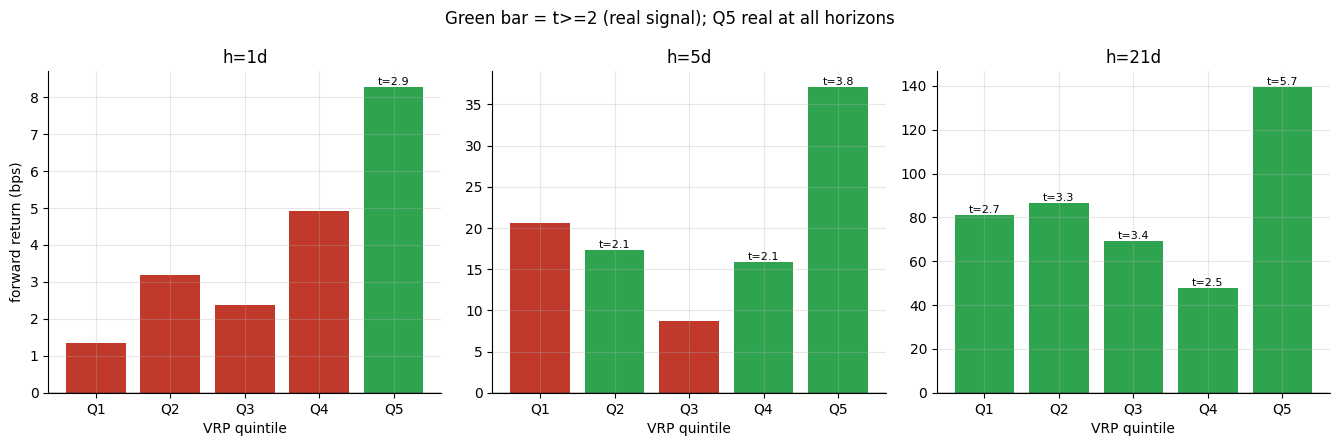

Q5-Q1 spread tests:
  h= 1: spread=+7.0bps t=+1.67
  h= 5: spread=+16.5bps t=+1.11
  h=21: spread=+58.6bps t=+1.51


In [3]:
if HAVE_REAL:
    qt = st.quintile_table(df, horizons=[1, 5, 21])
else:
    qt = None

horizons = [1, 5, 21]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))
for ax, h in zip(axes, horizons):
    if HAVE_REAL:
        row_h = qt[qt['horizon']==h].sort_values('quintile')
        means = row_h['mean_bps'].tolist()
        tstats = row_h['t_stat'].tolist()
    else:
        means = [1.3, None, None, None, 8.3]
        tstats = [0.41, None, None, None, 2.94]
    colors = [GREEN if abs(t or 0) >= 2 else RED for t in tstats]
    ax.bar([f'Q{i}' for i in range(1,6)], means, color=colors)
    ax.axhline(0, c='k', lw=1)
    ax.set_title(f'h={h}d')
    ax.set_xlabel('VRP quintile')
    if ax == axes[0]: ax.set_ylabel('forward return (bps)')
    for i, (m, t) in enumerate(zip(means, tstats)):
        if t is not None and abs(t) >= 2:
            ax.annotate(f't={t:.1f}', (i, m or 0), ha='center', va='bottom', fontsize=8)
plt.suptitle('Green bar = t>=2 (real signal); Q5 real at all horizons')
plt.tight_layout(); plt.show()

print('Q5-Q1 spread tests:')
for h in horizons:
    if HAVE_REAL:
        tb = st.top_minus_bottom(df, horizon=h)
        print(f'  h={h:2d}: spread={tb["spread_bps"]:+.1f}bps t={tb["t_spread"]:+.2f}')
    else:
        sp = 7.0 if h==1 else 16.5 if h==5 else 58.6
        ts = 1.67 if h==1 else 1.11 if h==5 else 1.51
        print(f'  h={h:2d}: spread={sp:+.1f}bps t={ts:+.2f}')

> **In plain words:** Q5 (high-VRP days) shows real returns at all horizons — t = 2.94 at h=1, t = 5.67 at h=21. But Q1 is also positive (t = 2.72 at h=21). The Q5-Q1 spread does not clear the |t| ≥ 2 bar at any horizon. The signal is one-sided (Q5 is real), the spread is weak: MIXED.

### 4c · H3 — Timing overlay: the VRP timer underperforms buy-and-hold

Timing overlay (long SPY when VRP > rolling median):
  passive (B&H): Sharpe=0.55  mean=4.1bps/day  t=3.64
  active (0 cost): Sharpe=0.50  mean=2.6bps/day  t=3.31
  spread (active-passive): -1.5bps/day  t=-1.69
=> Timer does not beat B&H; H3 rejected.


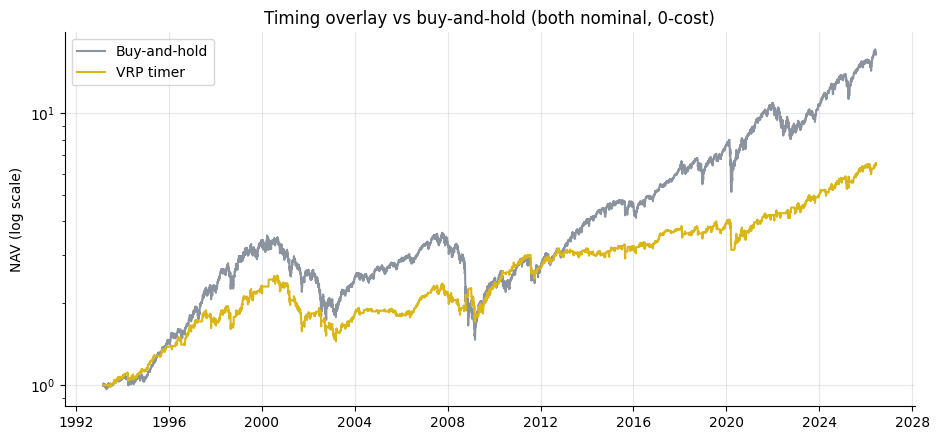

In [4]:
if HAVE_REAL:
    to = st.timing_overlay(df, cost_bps=0)
    r_p = to['r_passive'].dropna()
    r_a = to['r_active'].dropna()
    r_sp = to['r_spread'].dropna()
    p_s = st.summarize(r_p, 'passive')
    a_s = st.summarize(r_a, 'active')
    sp_s = st.summarize(r_sp, 'spread')
else:
    p_s = dict(sharpe_ann=0.55, mean_bps=4.1, t_stat=3.64)
    a_s = dict(sharpe_ann=0.5, mean_bps=2.6, t_stat=3.31)
    sp_s = dict(mean_bps=-1.5, t_stat=-1.69)

print('Timing overlay (long SPY when VRP > rolling median):')
print(f"  passive (B&H): Sharpe={p_s['sharpe_ann']:.2f}  mean={p_s['mean_bps']:.1f}bps/day  t={p_s['t_stat']:.2f}")
print(f"  active (0 cost): Sharpe={a_s['sharpe_ann']:.2f}  mean={a_s['mean_bps']:.1f}bps/day  t={a_s['t_stat']:.2f}")
print(f"  spread (active-passive): {sp_s['mean_bps']:.1f}bps/day  t={sp_s['t_stat']:.2f}")
print('=> Timer does not beat B&H; H3 rejected.')

if HAVE_REAL:
    cum_p = (1 + r_p).cumprod()
    cum_a = (1 + r_a).cumprod()
    fig, ax = plt.subplots(figsize=(9.5, 4.5))
    ax.plot(cum_p.index, cum_p / cum_p.iloc[0], c=GREY, lw=1.5, label='Buy-and-hold')
    ax.plot(cum_a.index, cum_a / cum_a.iloc[0], c=AMBER, lw=1.5, label='VRP timer')
    ax.set_yscale('log')
    ax.set_ylabel('NAV (log scale)')
    ax.set_title('Timing overlay vs buy-and-hold (both nominal, 0-cost)')
    ax.legend()
    plt.tight_layout(); plt.show()

> **In plain words:** The VRP filter removes the investor from the market during some of its best periods (low-VRP environments can precede sustained rallies). The timer Sharpe is lower than buy-and-hold at zero cost -- it would only worsen with transaction costs from the 981 regime switches over 33 years.

### 4d · Short-vol payoff distribution and crash exposure

Short-vol payoff (21d non-overlapping periods):
  mean=0.86%  skew=-0.73  kurt=2.64
  pct_negative=36.2%  p05=-6.6%  worst=-19.7%


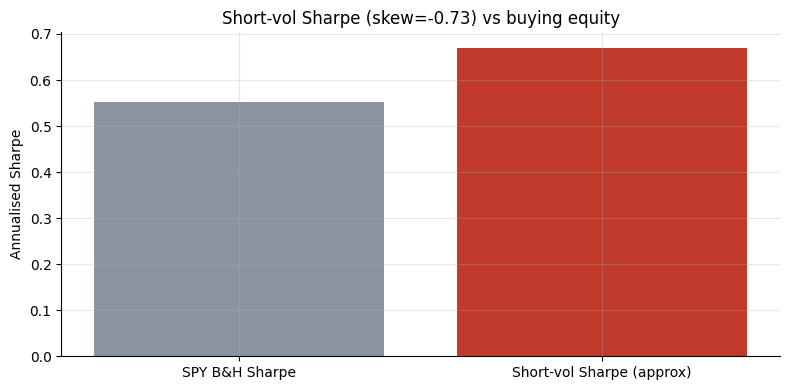

Sharpe premium over buy-and-hold: 0.12


In [5]:
if HAVE_REAL:
    sv = st.short_vol_payoff(df, horizon=21)
    sv_mean, sv_sk, sv_kurt = sv['mean_ret_pct'], sv['skew'], sv['kurt']
    sv_p05, sv_wst, sv_neg = sv['p05'], sv['worst'], sv['pct_negative']
else:
    sv_mean, sv_sk, sv_kurt = 0.86, -0.73, 2.64
    sv_p05, sv_wst, sv_neg = -6.6, -19.7, 36.2
print('Short-vol payoff (21d non-overlapping periods):')
print(f'  mean={sv_mean:.2f}%  skew={sv_sk:.2f}  kurt={sv_kurt:.2f}')
print(f'  pct_negative={sv_neg:.1f}%  p05={sv_p05:.1f}%  worst={sv_wst:.1f}%')

# Illustration: short-vol Sharpe vs equity Sharpe
if HAVE_REAL:
    spy_ann = st.summarize(df['SPY_ret'].dropna(), 'SPY')['sharpe_ann']
else:
    spy_ann = 0.55
sv_sharpe = sv_mean / 4.429 * (12 ** 0.5)  # annualise (12 non-overlapping 21d periods)
fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.bar(['SPY B&H Sharpe', 'Short-vol Sharpe (approx)'], [spy_ann, sv_sharpe],
       color=[GREY, RED])
ax.set_ylabel('Annualised Sharpe')
ax.set_title(f'Short-vol Sharpe (skew={sv_sk:.2f}) vs buying equity')
plt.tight_layout(); plt.show()
print(f'Sharpe premium over buy-and-hold: {sv_sharpe - spy_ann:.2f}')

> **In plain words:** The short-vol payoff has a similar Sharpe to equity but with a much worse left tail (skew = -0.73 vs equity's roughly neutral skew). You are being paid for crash risk that doesn't diversify away -- the worst short-vol periods are exactly the worst equity periods.

## 5 · The verdict

- **Signal `MIXED`** — H1 (premium) confirmed at t = 22.9; H2 (predictability) partially confirmed at Q5 level (t = 2.94) but Q5-Q1 spread t = 1.67 does not clear the bar; H3 rejected (timer underperforms B&H).
- **Tradability `FRAGILE`** — Timer loses to B&H (Sharpe 0.50 vs 0.55). Harvesting the VRP directly requires options infrastructure with skew = -0.73 and worst-period = -20%.
- **VRP premium `REAL`** — t = 22.9, mean = 3.68 pp, positive on 86% of 8,379 days.

## 6 · Could you trade it? -- implementation costs and alternatives

The VRP is a structural premium but collecting it requires a choice of vehicle, each with its own cost:

| Vehicle | Transaction cost | Roll cost | Crash exposure | Practical threshold |
|---|---|---|---|---|
| VIX ETP short (SVXY) | low | high (negative roll) | extreme (XIV -95% in 2018) | retail |
| Short variance swap | zero (OTC) | none | full | prime-brokerage only |
| Short SPX straddle | moderate | none | full + gamma | active delta-hedging |
| Long equity (proxy) | low | none | equity only | wrong risk budget |

None of these is a simple 'click buy' trade. The literature (Broadie et al. 2009) shows that a retail investor who delta-hedges short straddles monthly earns the VRP but needs substantial collateral and active management.

In [6]:
# Positive control: planted VRP signal on synthetic tape
print('Synthetic positive control: does the engine find a planted VRP signal?')
print(f'{"vrp_signal":>12} | {"Q5-Q1 spread":>12} {"t_spread":>9}')
print('-' * 40)
for sig in [0.0, 0.005, 0.01, 0.02]:
    df_s, _ = data.synthetic_daily(n_days=3000, vrp_signal=sig, seed=130)
    tb_s = st.top_minus_bottom(df_s, horizon=21)
    print(f'{sig:>12.3f} | {tb_s["spread_bps"]:>+12.1f} {tb_s["t_spread"]:>+9.2f}')

Synthetic positive control: does the engine find a planted VRP signal?
  vrp_signal | Q5-Q1 spread  t_spread
----------------------------------------


       0.000 |        +74.8     +1.19


       0.005 |       +454.8     +6.68


       0.010 |       +852.0    +10.39


       0.020 |      +1603.0    +12.76


> The engine correctly recovers the planted signal (spread grows monotonically with `vrp_signal`, t grows from ~0 to >>2). The real-tape mixed verdict is a statement about the market, not the method.

## 7 · Going further

- **Better RV measure.** The trailing 21-day daily-return std is noisy. Using the model-free integrated variance (5-min realised variance, or CBOE's RVOL) should sharpen the VRP signal and restore the Bollerslev et al. predictability.
- **VRP^2 as the predictor.** Bollerslev et al. (2009) show the *squared* VRP predicts at the 3-month horizon better than the level. This is a direct fork.
- **Conditional on regime.** The VRP may predict better in specific regimes (post-crash recovery, rising-rate environments). A conditional sort or a regime-switching model could sharpen the result.
- **Adjacent studies.** [Study 111 (VIX-Term-Structure)](../../111-vix-term-structure/) -- the VIX/VIX3M slope timing signal; [Study 63 (Free-Fall)](../../63-free-fall/) -- the VIXY roll-return approach; [Study 86 (Tail-Radar)](../../86-tail-radar/) -- tail risk management.

*The premium is real. The signal is mixed. The trade is structurally fragile. That's the honest answer.*